In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.style.use('seaborn-v0_8-white')
%matplotlib inline
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

In [2]:
df = pd.read_csv('data/cardiac_failure_processed.csv')
df1 = pd.read_csv('data/cardio_base.csv', sep=';')

In [3]:
print(df.shape)
df.head()

(70000, 14)


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,0.588076,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,0.730159,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,0.624003,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,0.528455,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,0.516918,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df1.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df['age'] = df1['age']/365
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
df.drop(columns=['Unnamed: 0', 'id'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 6.4 MB


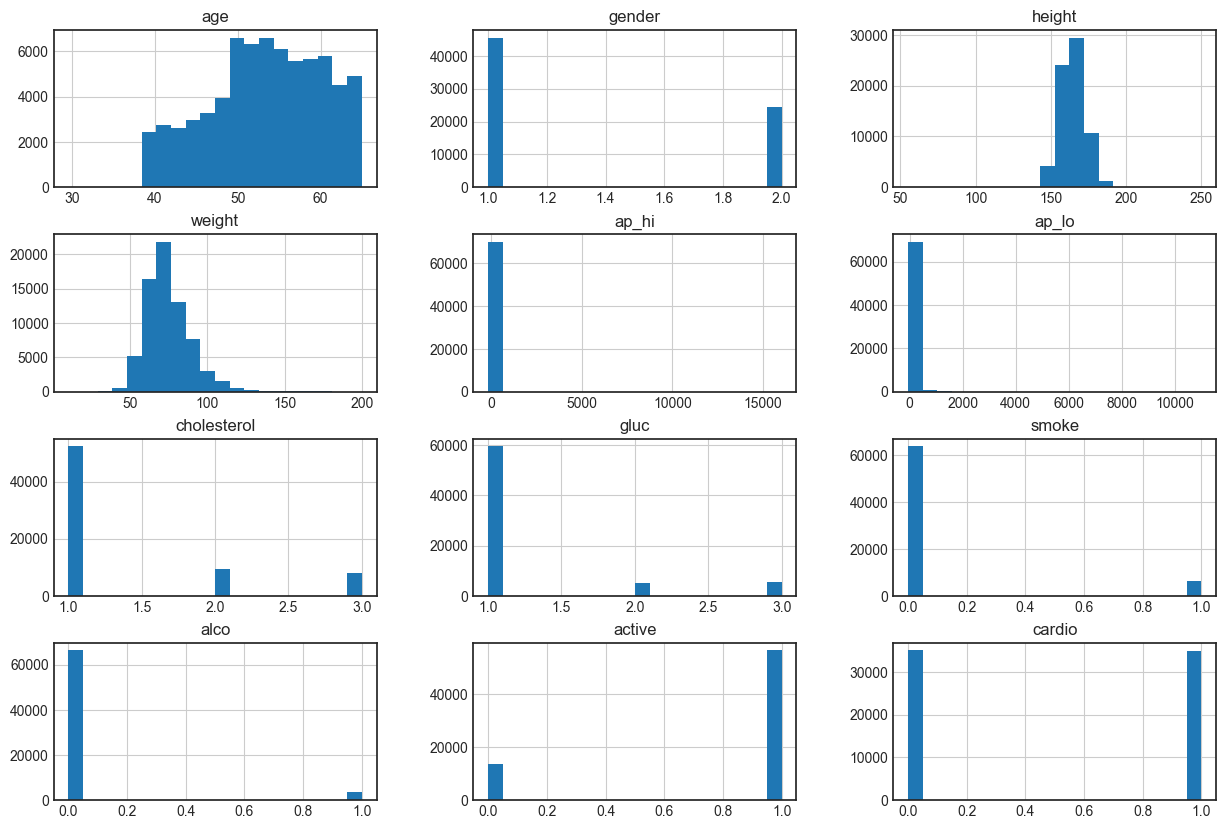

In [7]:
df.hist(figsize=(15, 10), bins=20)
plt.show()

In [8]:
df['gender'] = df['gender'].map({1: 1, 2: 0})
df['height'] = df['height'].astype(float)

df['bmi'] = df['weight'] / (df['height'] / 100) ** 2

df['ap_hi'] = df['ap_hi'].astype(float)
df['ap_lo'] = df['ap_lo'].astype(float)

In [9]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,50.391781,0,168.0,62.0,110.0,80.0,1,1,0,0,1,0,21.967120
1,55.419178,1,156.0,85.0,140.0,90.0,3,1,0,0,1,1,34.927679
2,51.663014,1,165.0,64.0,130.0,70.0,3,1,0,0,0,1,23.507805
3,48.282192,0,169.0,82.0,150.0,100.0,1,1,0,0,1,1,28.710479
4,47.873973,1,156.0,56.0,100.0,60.0,1,1,0,0,0,0,23.011177


In [10]:
df = df.loc[(df['weight'] > 35) & (df['height'] > 90), :].reset_index(drop=True)

df.loc[df['ap_lo'] > 500, 'ap_lo'] = df.loc[df['ap_lo'] > 500, 'ap_lo'] / 10
df.loc[df['ap_lo'] > 500, 'ap_lo'] = df.loc[df['ap_lo'] > 500, 'ap_lo'] / 10
df = df.loc[df['ap_lo'] > 0, :].reset_index(drop=True)
df = df.loc[df['ap_hi'] > df['ap_lo'], :].reset_index(drop=True)
df = df.loc[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200), :].reset_index(drop=True)

df.loc[df['ap_hi'] > 500, 'ap_hi'] = df.loc[df['ap_hi'] > 500, 'ap_hi'] / 10
df.loc[df['ap_hi'] > 500, 'ap_hi'] = df.loc[df['ap_hi'] > 500, 'ap_hi'] / 10
df = df.loc[df['ap_hi'] < 500, :].reset_index(drop=True)

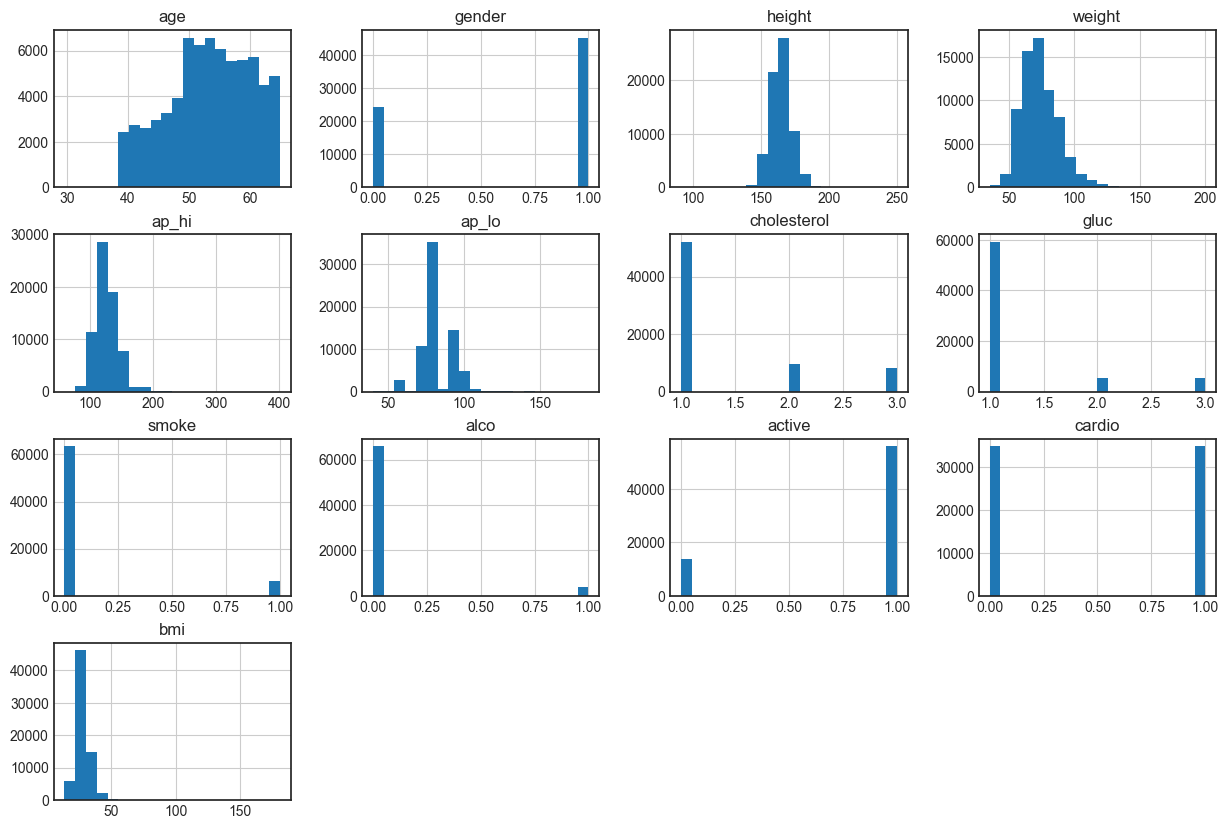

In [11]:
df.hist(figsize=(15, 10), bins=20)
plt.show()

In [12]:
feature_list = list(df.columns)
feature_list.remove('cardio')
df = df[feature_list + ['cardio']]
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,cardio
0,50.391781,0,168.0,62.0,110.0,80.0,1,1,0,0,1,21.967120,0
1,55.419178,1,156.0,85.0,140.0,90.0,3,1,0,0,1,34.927679,1
2,51.663014,1,165.0,64.0,130.0,70.0,3,1,0,0,0,23.507805,1
3,48.282192,0,169.0,82.0,150.0,100.0,1,1,0,0,1,28.710479,1
4,47.873973,1,156.0,56.0,100.0,60.0,1,1,0,0,0,23.011177,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69608 entries, 0 to 69607
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          69608 non-null  float64
 1   gender       69608 non-null  int64  
 2   height       69608 non-null  float64
 3   weight       69608 non-null  float64
 4   ap_hi        69608 non-null  float64
 5   ap_lo        69608 non-null  float64
 6   cholesterol  69608 non-null  int64  
 7   gluc         69608 non-null  int64  
 8   smoke        69608 non-null  int64  
 9   alco         69608 non-null  int64  
 10  active       69608 non-null  int64  
 11  bmi          69608 non-null  float64
 12  cardio       69608 non-null  int64  
dtypes: float64(6), int64(7)
memory usage: 6.9 MB


In [14]:
num_features = df.select_dtypes(include=['float64']).columns.tolist()
cat_features = df.select_dtypes(include=['int64']).columns.tolist()
cat_features.remove('cardio')

In [15]:
df.to_csv('model/cleaned_data.csv', index=False)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['cardio']),
    df['cardio'],
    test_size=0.2,
    random_state=42,
    stratify=df['cardio']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=int(df.shape[0]*.2),
    random_state=42,
    stratify=y_train
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (41765, 12) (41765,)
Validation set shape: (13921, 12) (13921,)
Test set shape: (13922, 12) (13922,)


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [18]:
preprocessor.fit(X_train)
processed_feature_names = preprocessor.get_feature_names_out()
processed_feature_names

X_train_scaled = preprocessor.transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

In [19]:
# standard_scaler = StandardScaler()
# standard_scaler.fit(X_train.select_dtypes(include=[float]))
# X_train_scaled = pd.DataFrame(standard_scaler.transform(X_train.select_dtypes(include=[float])), columns=X_train.select_dtypes(include=[float]).columns)
# X_val_scaled = pd.DataFrame(standard_scaler.transform(X_val.select_dtypes(include=[float])), columns=X_val.select_dtypes(include=[float]).columns)
# X_test_scaled = pd.DataFrame(standard_scaler.transform(X_test.select_dtypes(include=[float])), columns=X_test.select_dtypes(include=[float]).columns)

In [20]:
# X_train_scaled = pd.concat([X_train_scaled, X_train.select_dtypes(include=[int]).reset_index(drop=True)], axis=1)
# X_val_scaled = pd.concat([X_val_scaled, X_val.select_dtypes(include=[int]).reset_index(drop=True)], axis=1)
# X_test_scaled = pd.concat([X_test_scaled, X_test.select_dtypes(include=[int]).reset_index(drop=True)], axis=1)

In [21]:
def val_performance(model, X_val_scaled, y_val):
    y_val_pred = model.predict(X_val_scaled)

    matrix = confusion_matrix(y_val, y_val_pred)

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix - Validation Set')
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 6))

    try:
        rocs = roc_curve(y_val, model.predict_proba(X_val_scaled)[:, 1])
        auc = roc_auc_score(y_val, model.predict_proba(X_val_scaled)[:, 1])
        ax.plot(rocs[0], rocs[1], label='AUC = {:.2f}'.format(auc))
    except AttributeError:
        rocs = roc_curve(y_val, model.decision_function(X_val_scaled))
        auc = roc_auc_score(y_val, model.decision_function(X_val_scaled))
        ax.plot(rocs[0], rocs[1], label='AUC = {:.2f}'.format(auc))
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve - Validation Set')
    ax.legend()
    plt.show()

    return y_val_pred, rocs, auc

/Users/moswai/Documents/Mos_DataScience/venv/kaggle/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/moswai/Documents/Mos_DataScience/venv/kaggle/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


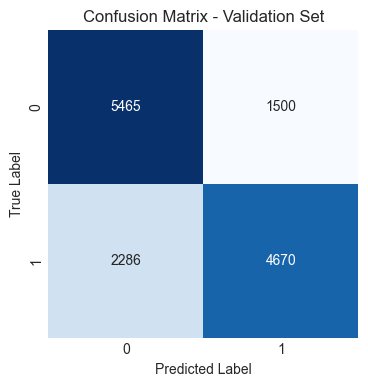

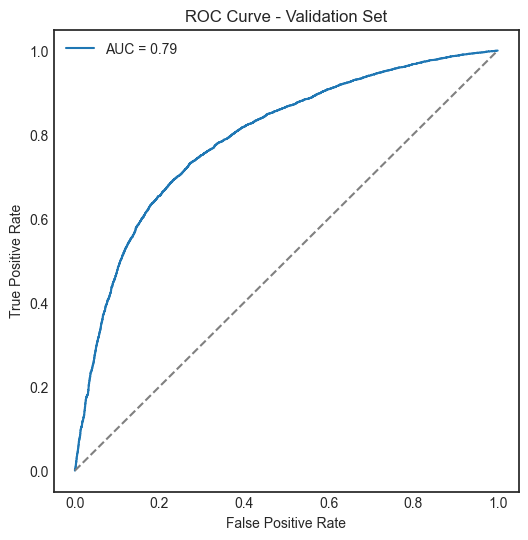

In [22]:
lr = LogisticRegression(penalty='l1', solver='saga', max_iter=10000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_val_pred_lr, rocs_lr, auc_lr = val_performance(lr, X_val_scaled, y_val)

In [23]:
fig = px.line(
    x=rocs_lr[0],
    y=rocs_lr[1],
    hover_data={'threshold': rocs_lr[2]},
    labels={'x': 'False Positive Rate', 'y': 'True Positive Rate'},
    title='ROC Curve - Logistic Regression (AUC = {:.2f})'.format(auc_lr),
    width=600,
    height=600
)

fig.show()

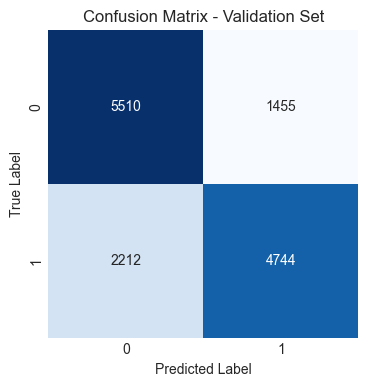

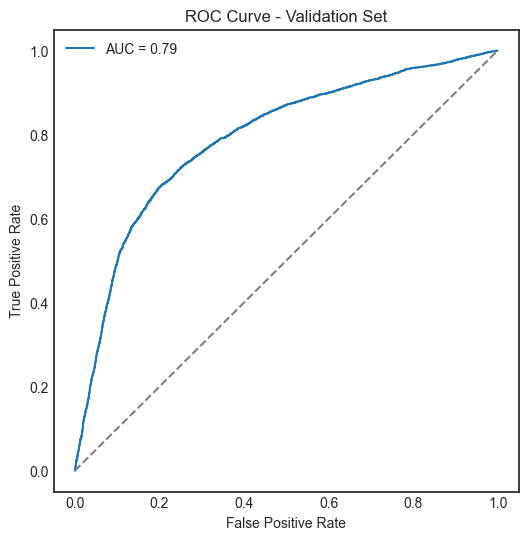

In [24]:
svc = SVC(random_state=42)

svc.fit(X_train_scaled, y_train)
y_val_pred_svc, rocs_svc, auc_svc = val_performance(svc, X_val_scaled, y_val)

In [25]:
def compare_roc(labels, rocs_list, aucs_list):
    fig, ax = plt.subplots(figsize=(6, 6))

    for rocs, label, auc in zip(rocs_list, labels, aucs_list):
        ax.plot(rocs[0], rocs[1], label=f"{label} (AUC = {auc:.2f})")

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve Comparison')
    ax.legend()
    plt.show()

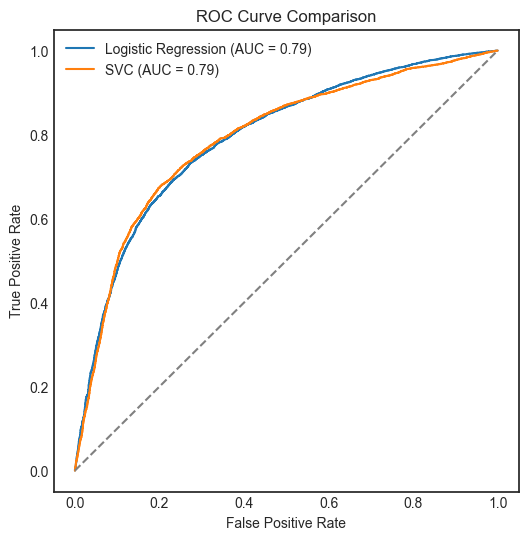

In [26]:
compare_roc(['Logistic Regression', 'SVC'], [rocs_lr, rocs_svc], [auc_lr, auc_svc])

In [27]:
compare_fig = go.Figure()

compare_fig.add_trace(
    go.Scatter(
        x=rocs_lr[0],
        y=rocs_lr[1],
        mode='lines',
        name='Logistic Regression (AUC = {:.2f})'.format(auc_lr),
        hovertemplate='FPR: %{x:.2f}<br>TPR: %{y:.2f}<br>Threshold: %{text:.2f}',
        text=rocs_lr[2],
        line=dict(color='blue')
    )
)

compare_fig.add_trace(
    go.Scatter(
        x=rocs_svc[0],
        y=rocs_svc[1],
        mode='lines',
        name='SVC (AUC = {:.2f})'.format(auc_svc),
        hovertemplate='FPR: %{x:.2f}<br>TPR: %{y:.2f}<br>Threshold: %{text:.2f}',
        text=rocs_svc[2],
        line=dict(color='red')
    )
)
compare_fig.update_layout(
    title='ROC Curve Comparison',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    width=800,
    height=800,
    legend=dict(x=0.6, y=0.1),
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1])
)

compare_fig.show()

In [28]:
# svc_param_grid = {
#     'kernel': ['rbf'],
#     'C': [10, 100, 1000],
#     'gamma': [.1, .01, .001]
# }

# grid_svc = GridSearchCV(SVC(random_state=42), param_grid=svc_param_grid, cv=10, n_jobs=-1, verbose=2)
# grid_svc.fit(X_train_scaled, y_train)

In [29]:
# grid_svc.best_params_

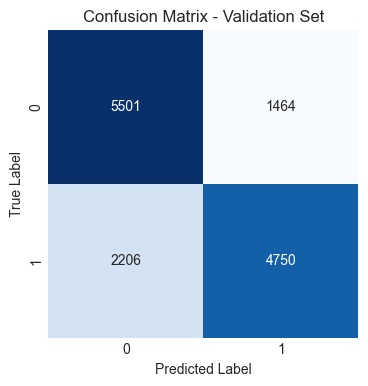

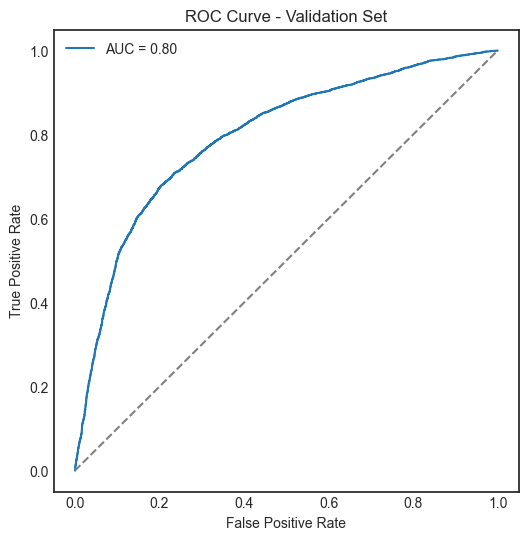

In [30]:
best_svc = SVC(kernel='rbf', C=100, gamma=.01, random_state=42)
best_svc.fit(X_train_scaled, y_train)
y_val_pred_best_svc = val_performance(best_svc, X_val_scaled, y_val)

In [31]:
y_val_pred_best_svc[1][0]

array([0.00000000e+00, 1.43575018e-04, 1.43575018e-04, ...,
       9.98851400e-01, 9.98851400e-01, 1.00000000e+00])

In [32]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        name='SVC',
        x=rocs_lr[0],
        y=rocs_lr[1],
        hovertemplate='FPR: %{x:.2f}<br>TPR: %{y:.2f}<br>Threshold: %{text:.2f}',
        text=rocs_lr[2]
    )
)

fig.update_layout(
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    title='ROC Curve - Best SVC Model (AUC: {:.2f})'.format(y_val_pred_best_svc[2]),
    width=600,
    height=600,
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1])
)

fig.show()

In [33]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

In [34]:
loadings = pd.DataFrame(
    pca.components_,
    columns=processed_feature_names,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

In [35]:
fig = go.Figure(data=go.Heatmap(
    z=loadings.values,
    x=loadings.columns,
    y=loadings.index,
    colorscale='RdBu',
    zmid=0,
    colorbar=dict(title='Loading Value')
))
fig.update_layout(
    title='PCA Loadings Heatmap',
    xaxis_title='Original Features',
    yaxis_title='Principal Components',
    width=600,
    height=600
)
fig.show()

In [36]:
pca.explained_variance_ratio_

array([0.34600034, 0.19289859, 0.17853475, 0.12909471, 0.03752933,
       0.02462276, 0.02291166, 0.02099368, 0.01545856, 0.01085046,
       0.00866572, 0.00587734, 0.00565714, 0.00090496])

In [37]:
per_var = np.round(pca.explained_variance_ratio_*100, decimals=1)
labels = [str(x) for x in range(1, len(per_var)+1)]

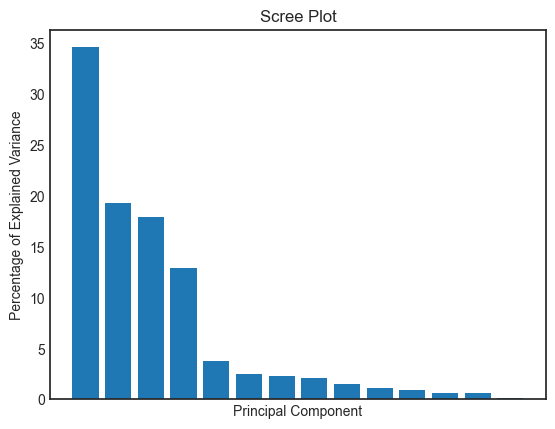

In [38]:
plt.bar(x=range(1, len(per_var)+1), height=per_var)
plt.tick_params(
    axis='x',
    which='both',
    bottom=False,
    top=False,
    labelbottom=False
)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

In [39]:
X_train_pca_2 = X_train_pca[:, :2]
X_val_pca_2 = pca.transform(X_val_scaled)[:, :2]
X_test_pca_2 = pca.transform(X_test_scaled)[:, :2]

In [40]:
# param_grid_pca_svc = {
#     'kernel': ['rbf'],
#     'C': [100, 1000],
#     'gamma': [.1, .01, .001]
# }

# grid_pca_svc = GridSearchCV(SVC(random_state=42), param_grid=param_grid_pca_svc, cv=10, n_jobs=-1, verbose=2)
# grid_pca_svc.fit(X_train_pca_2, y_train)

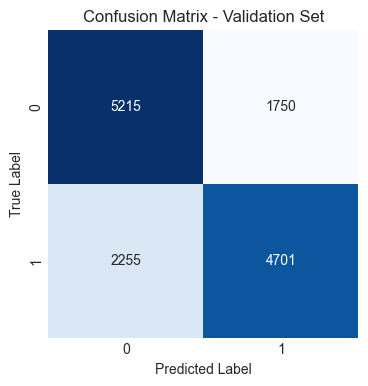

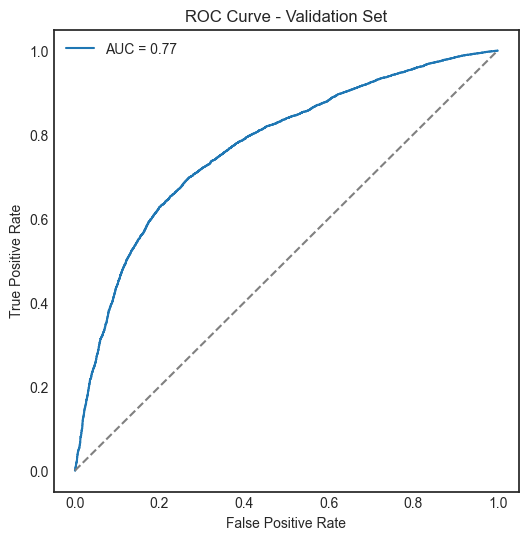

In [41]:
# best_svc_pca = SVC(random_state=42, **grid_pca_svc.best_params_)
best_svc_pca = SVC(kernel='rbf', C=100, gamma=.001, random_state=42)
best_svc_pca.fit(X_train_pca_2, y_train)
y_val_pred_best_svc_pca = val_performance(best_svc_pca, X_val_pca_2, y_val)

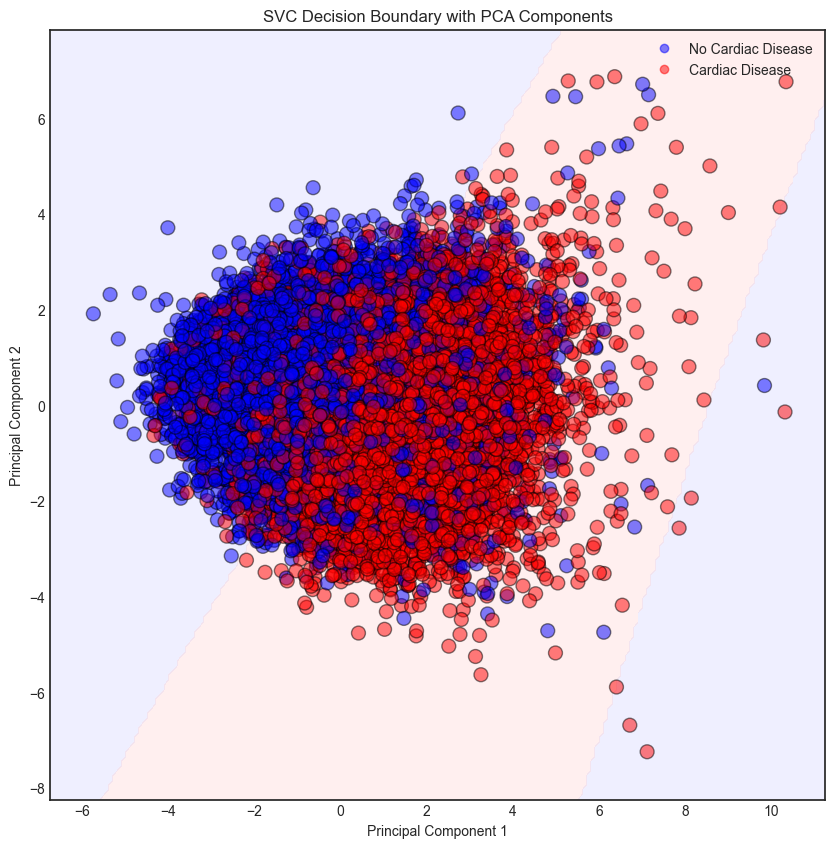

In [42]:
# Josh Starmer
# https://www.youtube.com/watch?v=8A7L0GsBiLQ

x_min = X_train_pca_2[:, 0].min() - 1
x_max = X_train_pca_2[:, 0].max() + 1
y_min = X_train_pca_2[:, 1].min() - 1
y_max = X_train_pca_2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = best_svc_pca.predict(np.column_stack((xx.ravel(), yy.ravel())))
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 10))
cmap = colors.ListedColormap(["#CCCCFF", "#FFCCCC"])
ax.contourf(xx, yy, Z, alpha=.3, cmap=cmap, levels=[-0.5, 0.5, 1.5])

cmap = colors.ListedColormap(['blue', 'red'])
scatter = ax.scatter(
    X_train_pca_2[:, 0],
    X_train_pca_2[:, 1],
    c=y_train,
    cmap=cmap,
    edgecolor='k',
    s=100,
    alpha=.5
)

legend = ax.legend(scatter.legend_elements()[0],
                   scatter.legend_elements()[1],
                   loc='upper right')
legend.get_texts()[0].set_text('No Cardiac Disease')
legend.get_texts()[1].set_text('Cardiac Disease')

ax.set_ylabel('Principal Component 2')
ax.set_xlabel('Principal Component 1')
ax.set_title('SVC Decision Boundary with PCA Components')
plt.show()

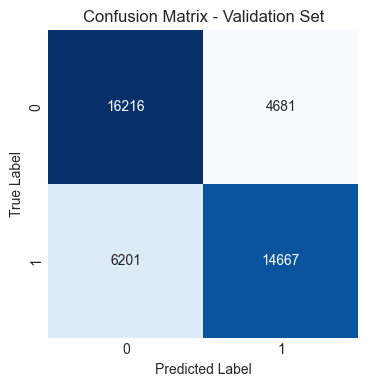

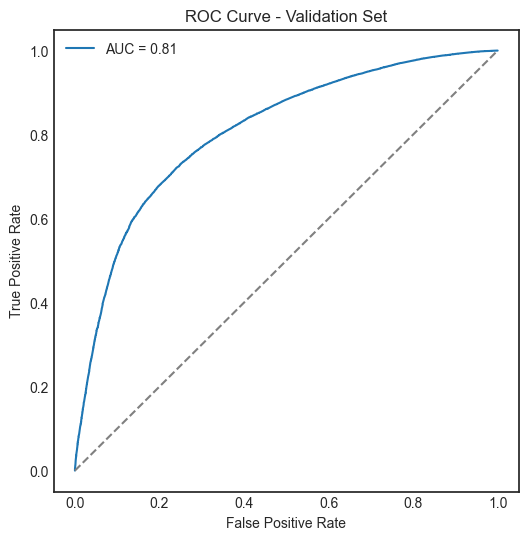

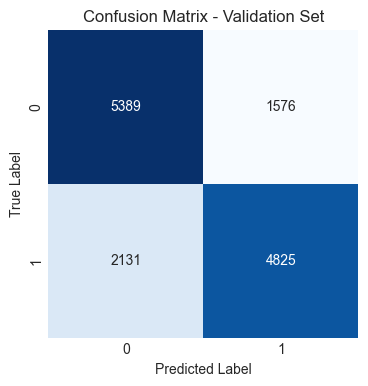

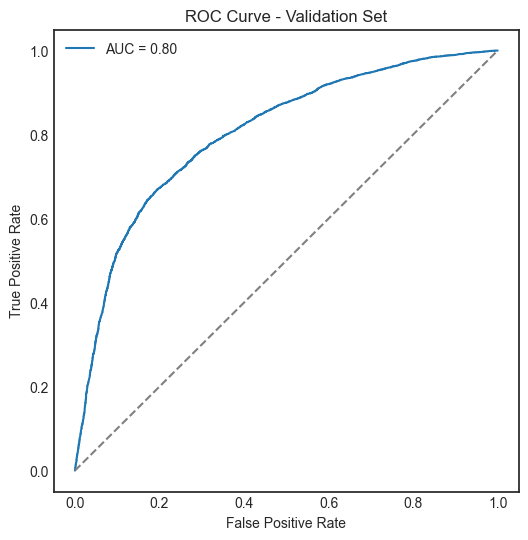

In [43]:
gb = GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_leaf_nodes=16, random_state=42)
gb.fit(X_train_scaled, y_train)
y_train_pred_gb, rocs_train_gb, auc_train_gb = val_performance(gb, X_train_scaled, y_train)
y_val_pred_gb, rocs_gb, auc_gb = val_performance(gb, X_val_scaled, y_val)

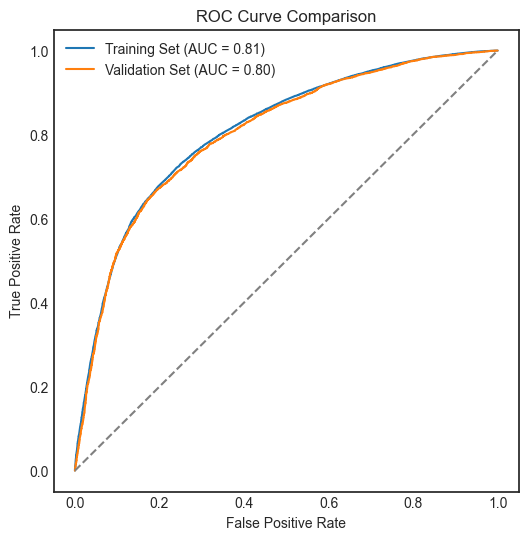

In [44]:
compare_roc(['Training Set', 'Validation Set'], [rocs_train_gb, rocs_gb], [auc_train_gb, auc_gb])

In [45]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        name='GBC',
        x=rocs_gb[0],
        y=rocs_gb[1],
        hovertemplate='FPR: %{x:.2f}<br>TPR: %{y:.2f}<br>Threshold: %{text:.2f}',
        text=rocs_gb[2]
    )
)

fig.update_layout(
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    title='ROC Curve - Best GBC Model (AUC: {:.2f})'.format(auc_gb),
    width=600,
    height=600,
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1])
)

fig.show()

In [46]:
import json

roc_data = {
    'fpr': rocs_gb[0].tolist(),
    'tpr': rocs_gb[1].tolist(),
    'thresholds': rocs_gb[2].tolist(),
    'auc': auc_gb
}

with open('model/roc_data.json', 'w') as f:
    json.dump(roc_data, f)

In [48]:
import joblib

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_leaf_nodes=16, random_state=42))
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "model/gbc_model.pkl")

['model/gbc_model.pkl']

In [66]:
X_val[:2].to_csv("model/required_data_format.csv", index=False)

In [45]:
# param_grid_gb = {
#     'learning_rate': [.01, .1, .2],
#     'n_estimators': [100, 250],
#     'max_leaf_nodes': [16, 32],
#     'subsample': [0.8, 1.0]
# }

# grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid=param_grid_gb, cv=10, n_jobs=-1, verbose=2)
# grid_gb.fit(X_train_scaled, y_train)

In [46]:
# best_gb_params = grid_gb.best_params_
# best_gb = GradientBoostingClassifier(**best_gb_params, random_state=42)
# best_gb.fit(X_train_scaled, y_train)
# y_train_pred_best_gb, rocs_train_best_gb, auc_train_best_gb = val_performance(best_gb, X_train_scaled, y_train)
# y_val_pred_best_gb, rocs_best_gb, auc_best_gb = val_performance(best_gb, X_val_scaled, y_val) 

In [47]:
# compare_roc(['Training Set', 'Validation Set'], [rocs_train_best_gb, rocs_best_gb], [auc_train_best_gb, auc_best_gb])

[0]	validation_0-logloss:0.62311
[1]	validation_0-logloss:0.58629
[2]	validation_0-logloss:0.56590
[3]	validation_0-logloss:0.55446
[4]	validation_0-logloss:0.54845
[5]	validation_0-logloss:0.54475
[6]	validation_0-logloss:0.54226
[7]	validation_0-logloss:0.54148
[8]	validation_0-logloss:0.54055
[9]	validation_0-logloss:0.54026
[10]	validation_0-logloss:0.54006
[11]	validation_0-logloss:0.53988
[12]	validation_0-logloss:0.53975
[13]	validation_0-logloss:0.53979
[14]	validation_0-logloss:0.53983
[15]	validation_0-logloss:0.53992
[16]	validation_0-logloss:0.53999
[17]	validation_0-logloss:0.53995
[18]	validation_0-logloss:0.53986
[19]	validation_0-logloss:0.54021
[20]	validation_0-logloss:0.54015
[21]	validation_0-logloss:0.54024
[22]	validation_0-logloss:0.54071
[23]	validation_0-logloss:0.54071
[24]	validation_0-logloss:0.54099
[25]	validation_0-logloss:0.54142
[26]	validation_0-logloss:0.54153
[27]	validation_0-logloss:0.54194
[28]	validation_0-logloss:0.54216
[29]	validation_0-loglos

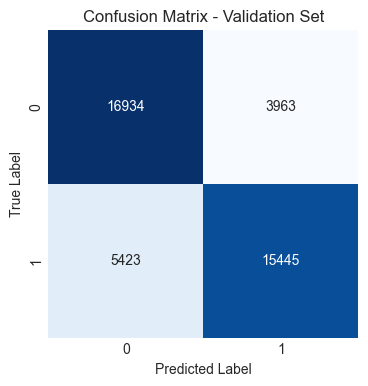

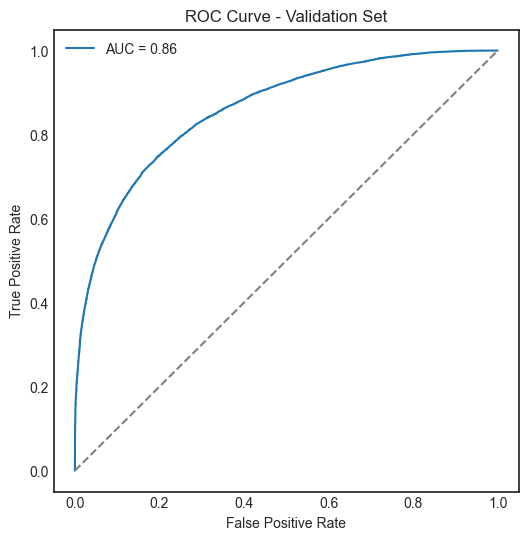

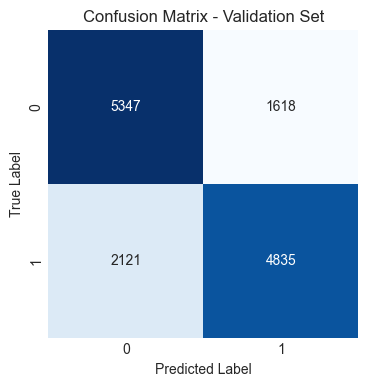

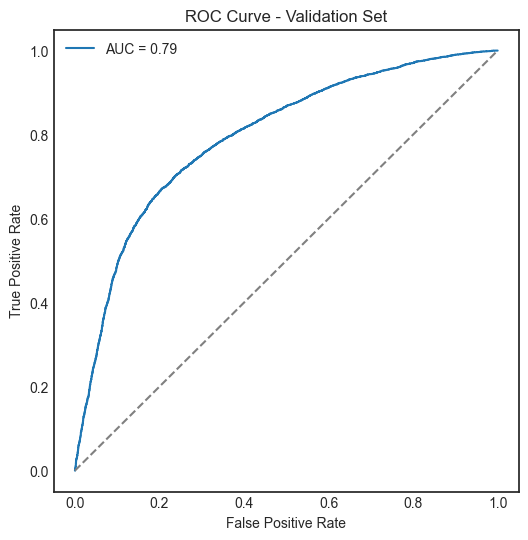

In [48]:
xg = xgb.XGBClassifier(objective='binary:logistic', seed=42)
xg.fit(X_train_scaled, 
       y_train,
       verbose=True,
       eval_set=[(X_val_scaled, y_val)]
       )
y_train_pred_xg, rocs_train_xg, auc_train_xg = val_performance(xg, X_train_scaled, y_train)
y_val_pred_xg, rocs_xg, auc_xg = val_performance(xg, X_val_scaled, y_val)

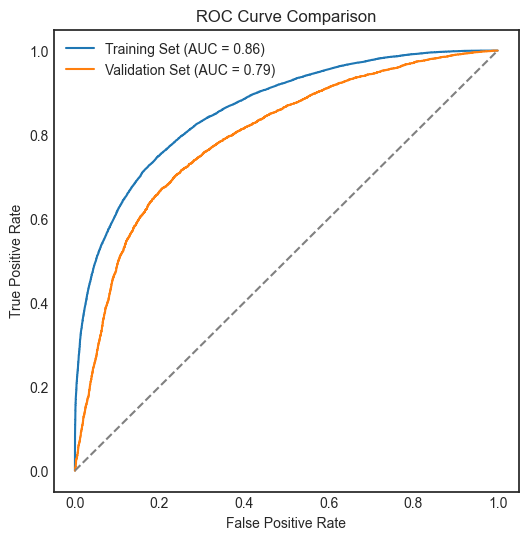

In [49]:
compare_roc(['Training Set', 'Validation Set'], [rocs_train_xg, rocs_xg], [auc_train_xg, auc_xg])

In [50]:
param_grid_xg = {
    'max_depth': [4, 5, 6],
    'learning_rate': [.05],
    'gamma': [.2, .4, .5, .6],
    # 'reg_lambda': [0, 1, 10]
}
grid_xg = GridSearchCV(xgb.XGBClassifier(objective='binary:logistic', seed=42), param_grid=param_grid_xg, cv=10, n_jobs=-1, verbose=2)
grid_xg.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.3s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.3s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=4; total time=   0.2s
[CV] END .........gamma=0.2, learning_rate=0.05, max_depth=5; total time=   0.3s
[CV] END .........gamma=0.2, learning_rate=0.0

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'gamma': [0.2, 0.4, ...], 'learning_rate': [0.05], 'max_depth': [4, 5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


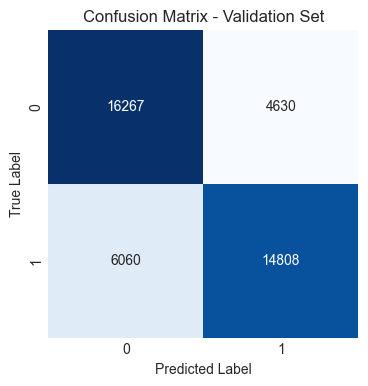

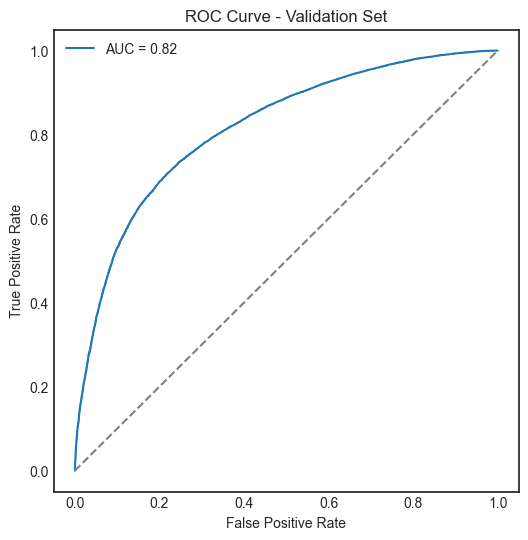

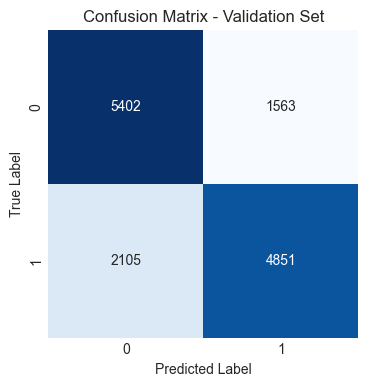

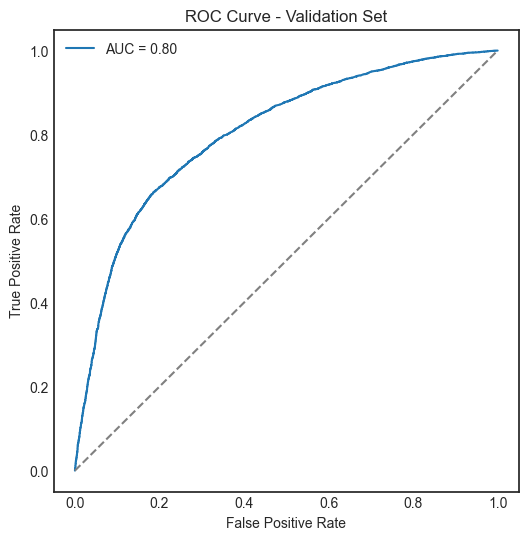

In [51]:
grid_xg_best_params = grid_xg.best_params_
xg_best = xgb.XGBClassifier(objective='binary:logistic', seed=42, subsample=.75, gamma=.5, learning_rate=.05, max_depth=5, random_state=42)
xg_best.fit(X_train_scaled, y_train)
y_train_pred_xg_best, rocs_train_xg_best, auc_train_xg_best = val_performance(xg_best, X_train_scaled, y_train)
y_val_pred_xg_best, rocs_xg_best, auc_xg_best = val_performance(xg_best, X_val_scaled, y_val)

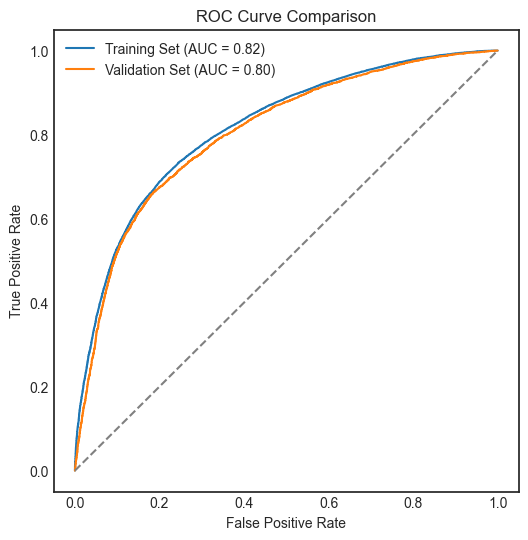

In [52]:
compare_roc(['Training Set', 'Validation Set'], [rocs_train_xg_best, rocs_xg_best], [auc_train_xg_best, auc_xg_best])

In [53]:
xg_1 = xgb.XGBClassifier(
    seed=42,
    objective='binary:logistic',
    subsample=.75,
    n_estimators=1,
    **grid_xg_best_params
)
xg_1.fit(X_train_scaled, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


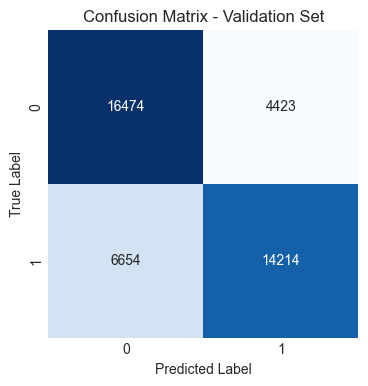

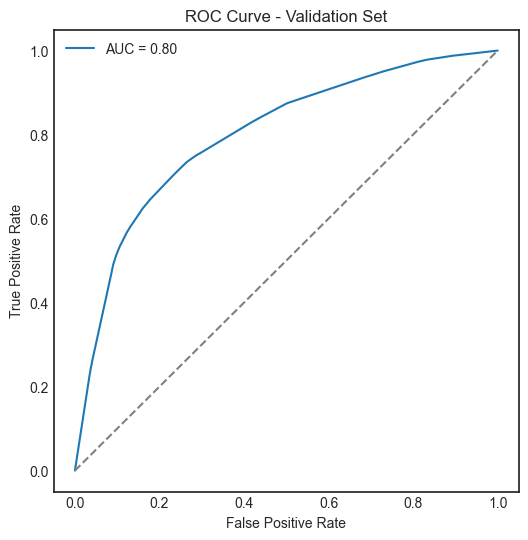

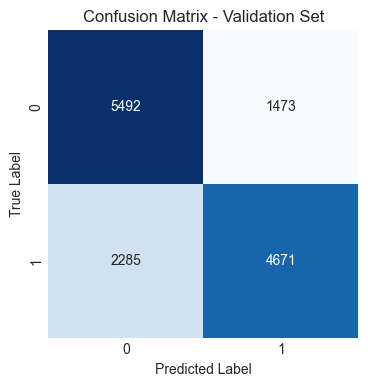

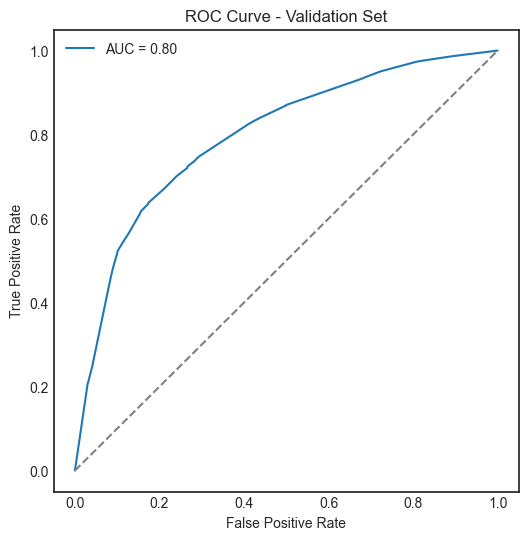

In [54]:
y_train_pred_xg_1, rocs_train_xg_1, auc_train_xg_1 = val_performance(xg_1, X_train_scaled, y_train)
y_val_pred_xg_1, rocs_xg_1, auc_xg_1 = val_performance(xg_1, X_val_scaled, y_val)

weight:  {'f0': 10.0, 'f1': 5.0, 'f2': 8.0, 'f3': 7.0, 'f4': 7.0, 'f5': 10.0, 'f7': 1.0, 'f8': 3.0, 'f10': 5.0, 'f11': 1.0, 'f12': 1.0, 'f13': 2.0}
gain:  {'f0': 104.1706771850586, 'f1': 5.711927890777588, 'f2': 8.476794242858887, 'f3': 948.2758178710938, 'f4': 8.081924438476562, 'f5': 12.272247314453125, 'f7': 13.805419921875, 'f8': 192.0845947265625, 'f10': 12.041450500488281, 'f11': 14.575141906738281, 'f12': 5.401788711547852, 'f13': 19.021697998046875}
cover:  {'f0': 1007.7244873046875, 'f1': 100.2999496459961, 'f2': 368.2810974121094, 'f3': 2502.070068359375, 'f4': 412.8926696777344, 'f5': 273.17486572265625, 'f7': 624.7496948242188, 'f8': 1883.4990234375, 'f10': 533.1497802734375, 'f11': 226.24989318847656, 'f12': 32.74998474121094, 'f13': 574.7496948242188}
total_gain:  {'f0': 1041.706787109375, 'f1': 28.55963897705078, 'f2': 67.8143539428711, 'f3': 6637.9306640625, 'f4': 56.57347106933594, 'f5': 122.72247314453125, 'f7': 13.805419921875, 'f8': 576.2537841796875, 'f10': 60.2072

/Users/moswai/Documents/Mos_DataScience/venv/kaggle/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


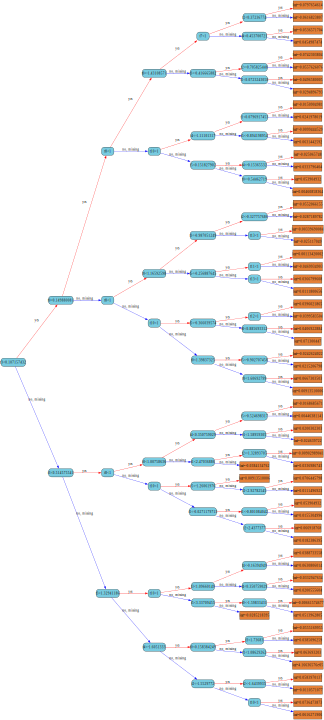

In [55]:
bst = xg_1.get_booster()
for importance_type in ['weight', 'gain', 'cover', 'total_gain', 'total_cover']:
    print('%s: ' % importance_type, bst.get_score(importance_type=importance_type))

node_params = {'shape': 'box',
               'style': 'filled, rounded',
               'fillcolor': '#78CBE0'}
leaf_params = {'shape': 'box',
               'style': 'filled',
               'fillcolor': '#E48038'}

graph = xgb.to_graphviz(
    bst,
    num_trees=0,
    size="10,10",
    rankdir="LR",
    condition_node_params=node_params,
    leaf_node_params=leaf_params
)

# from graphviz.backend import dot_command

# dot_command.DOT_BINARY = "/opt/homebrew/bin/dot"

from IPython.display import display
display(graph)

# graph.render("tree_visual")